Clinical Data

In [16]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
hgsoc_tcga_gdc_clinical_cleaned = pd.read_csv("../data/processed/hgsoc_tcga_gdc_clinical_cleaned.csv")
tcga_ov_imaging_cleaned = pd.read_csv("../data/processed/tcga_ov_imaging_cleaned.csv")

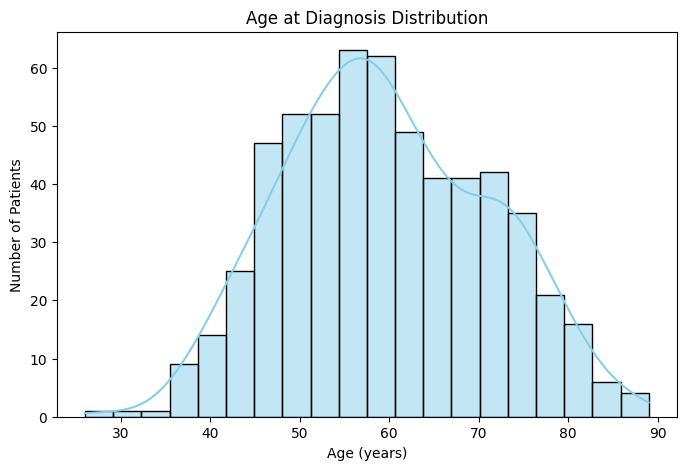

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(hgsoc_tcga_gdc_clinical_cleaned['diagnosis_age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Age at Diagnosis Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.show()

FIGO Stage Distribution

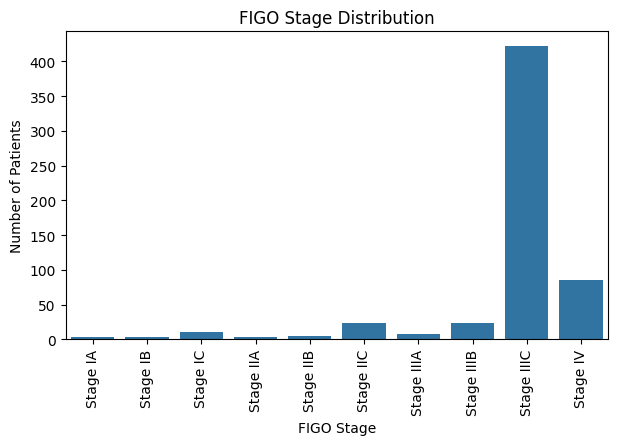

In [6]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=hgsoc_tcga_gdc_clinical_cleaned,
    x=hgsoc_tcga_gdc_clinical_cleaned['figo_stage'].astype(str).str.strip(),
    order=[x for x in sorted(hgsoc_tcga_gdc_clinical_cleaned['figo_stage'].dropna().unique())]
)

plt.title('FIGO Stage Distribution')
plt.xlabel('FIGO Stage')
plt.ylabel('Number of Patients')
plt.xticks(rotation=90)
plt.show()

Disease-free months distribution

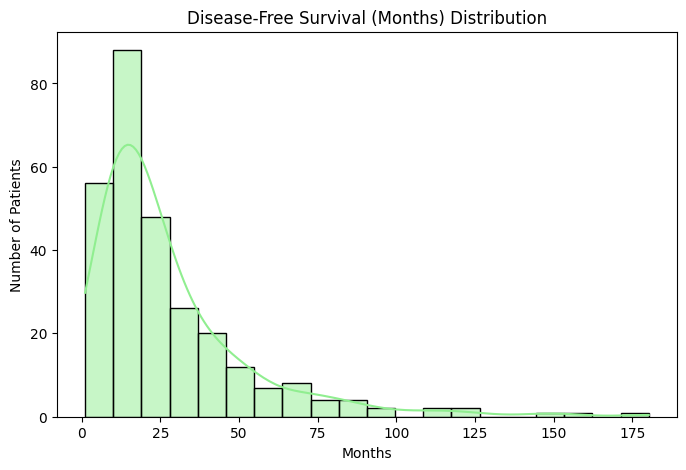

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(hgsoc_tcga_gdc_clinical_cleaned['disease_free_(months)'].dropna(), bins=20, kde=True, color='lightgreen')
plt.title('Disease-Free Survival (Months) Distribution')
plt.xlabel('Months')
plt.ylabel('Number of Patients')
plt.show()

Tumor Mutation Burden (TMB) distribution

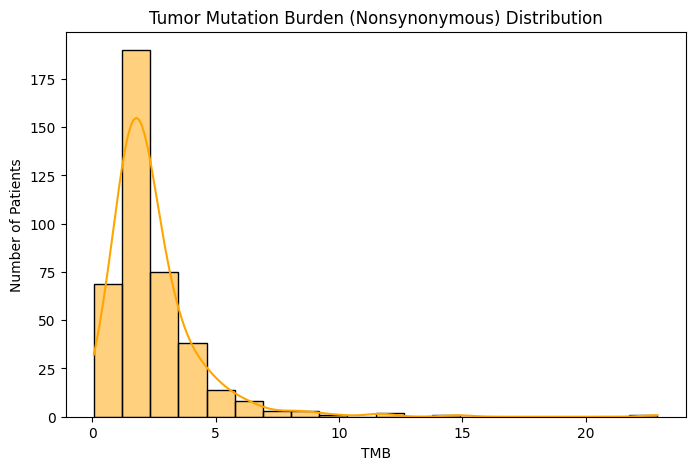

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(hgsoc_tcga_gdc_clinical_cleaned['tmb_(nonsynonymous)'].dropna(), bins=20, kde=True, color='orange')
plt.title('Tumor Mutation Burden (Nonsynonymous) Distribution')
plt.xlabel('TMB')
plt.ylabel('Number of Patients')
plt.show()

Fraction genome altered distribution

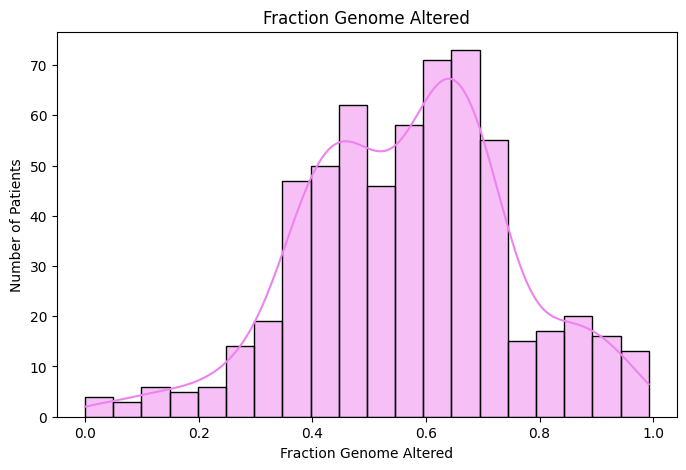

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(hgsoc_tcga_gdc_clinical_cleaned['fraction_genome_altered'].dropna(), bins=20, kde=True, color='violet')
plt.title('Fraction Genome Altered')
plt.xlabel('Fraction Genome Altered')
plt.ylabel('Number of Patients')
plt.show()

Imaging Data

Patient Data Distribution

In [19]:
tcga_ov_imaging_cleaned['patient_age_numeric'] = (
    tcga_ov_imaging_cleaned['patient_age']
    .str.replace('Y', '', regex=False)     
    .str.lstrip('0')                       
    .replace('', np.nan)                   
    .astype(float)                      
)

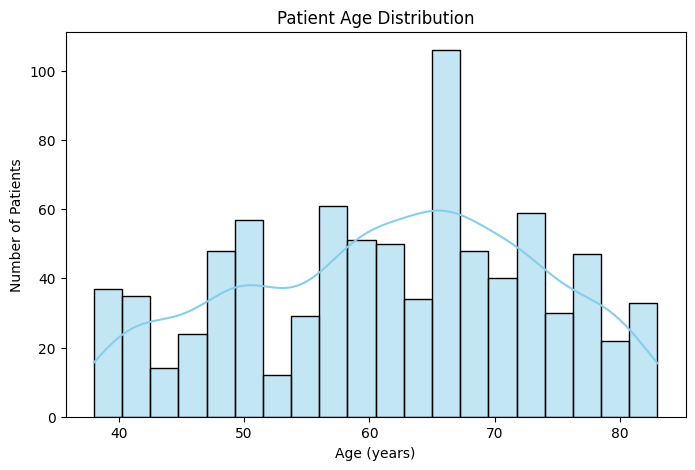

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(tcga_ov_imaging_cleaned['patient_age_numeric'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.show()

Distribution of Software Versions

C:\Users\User\AppData\Local\Temp\ipykernel_6984\191292083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


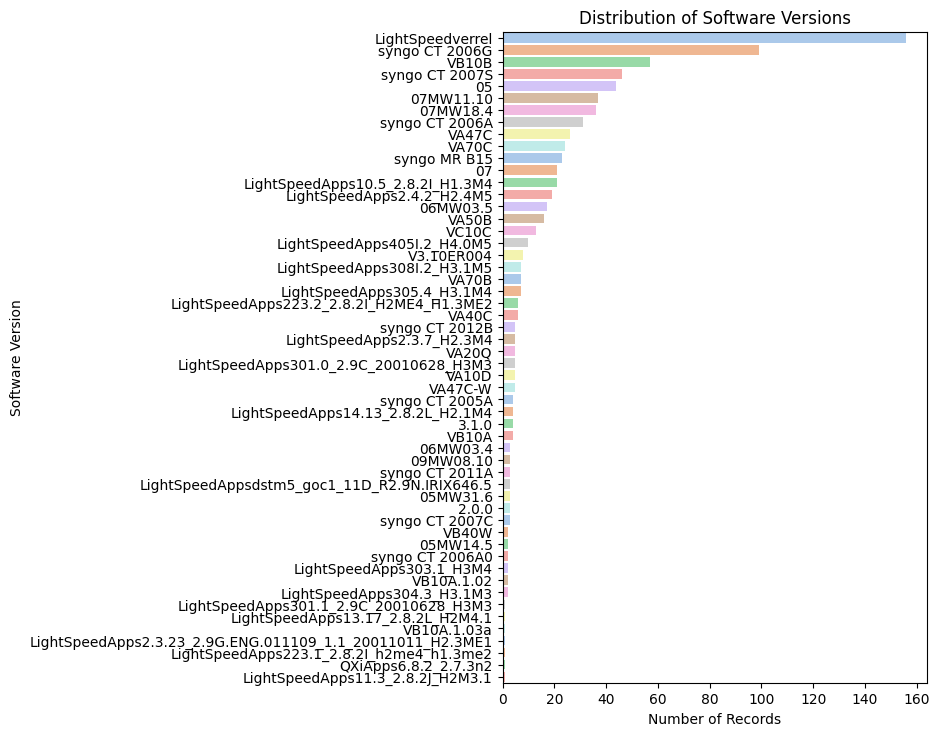

In [22]:
plt.figure(figsize=(10,8))

sns.countplot(
    y=tcga_ov_imaging_cleaned['software_versions'].astype(str).str.strip(),
    order=tcga_ov_imaging_cleaned['software_versions'].value_counts().index,
    palette="pastel",
    hue=None,
    dodge=False
)
plt.title('Distribution of Software Versions')
plt.xlabel('Number of Records')
plt.ylabel('Software Version')
plt.yticks(ticks=plt.yticks()[0], labels=plt.yticks()[1], fontsize=10) 
plt.tight_layout(pad=3) 
plt.show()

Study Description Distribution (Top 10)

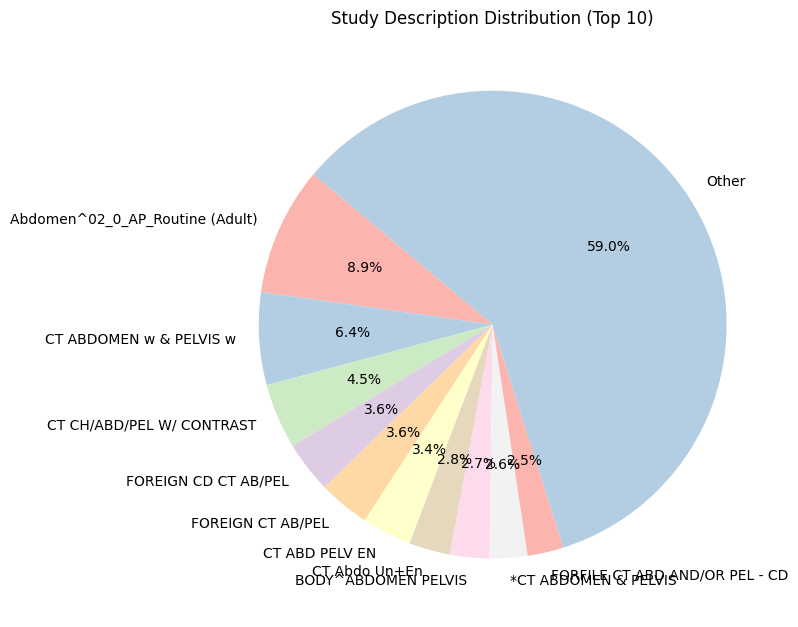

In [13]:
study_counts = tcga_ov_imaging_cleaned['study_description'].astype(str).str.strip().value_counts()
top_n = 10
top_counts = study_counts[:top_n]
other_count = study_counts[top_n:].sum()
top_counts['Other'] = other_count
plt.figure(figsize=(8,8))
plt.pie(
    top_counts,
    labels=top_counts.index,
    autopct='%1.1f%%',  
    startangle=140,
    colors=plt.cm.Pastel1.colors
)
plt.title('Study Description Distribution (Top 10)')
plt.tight_layout()
plt.show()